In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
from scipy.stats import randint, uniform

## IMPORT & EXPLORE

In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

In [3]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to('cpu')
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [4]:
from sentence_transformers import SentenceTransformer

In [5]:
from torchvision import transforms
from PIL import Image
import torch

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
all_products_combined = pd.read_csv(r"C:\Users\User\Desktop\flip_vlm\flip_data_vlm\all_products_combined_ext.csv") 

In [7]:
all_products_combined = all_products_combined.drop(columns = ['Unnamed: 0'])

In [8]:
from pathlib import Path

def convert_to_windows_path(local_path):
    if "flip/data/" in local_path:
        relative = local_path.split("flip/data/")[-1]
        return str(Path(
            "C:/Users/User/Desktop/flip_vlm/flip_data_vlm"
        ) / relative)
    elif "flo_images/" in local_path:
        relative = local_path.split("flo_images/")[-1]
        return str(Path(
            "C:/Users/User/Desktop/flip_vlm/flip_data_vlm/flo_images"
        ) / relative)
    else:
        return ""

all_products_combined['windows_image_path'] = (
    all_products_combined['local_image_path']
    .fillna("")
    .astype(str)
    .apply(convert_to_windows_path)
)


In [9]:
all_products_combined.sample(10)

,title,local_image_path,product_url,windows_image_path
19356,Очиститель кожи вакуумный КТ-3126,/root/flip/data/category_3/images/Очиститель_к...,https://www.flip.kz/catalog?prod=2661911,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...
2970,Стекло защитное для Xiaomi Redmi 9,/root/flip/data/category_4/images/Стекло_защит...,https://www.flip.kz/catalog?prod=2497701,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...
26649,Женский Ботинки Бежевый,/flo_images/e27e42e375d5_3a562bef.jpg,https://www.flo.com.kz/ru/product/kinetix-juna...,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\f...
21723,Термопот GL 0610,/root/flip/data/category_3/images/Термопот_GL_...,https://www.flip.kz/catalog?prod=4164701,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...
4827,Модуль памяти Hynix HMAG68EXNEA DDR4-3200 1Rx8...,/root/flip/data/category_4/images/Модуль_памят...,https://www.flip.kz/catalog?prod=4300095,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...
20111,Гриль-духовка,/root/flip/data/category_3/images/Гриль_духовк...,https://www.flip.kz/catalog?prod=3128013,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...
13051,Средство для мытья полов и стен «Лимон»,/root/flip/data/category_2/images/Средство_для...,https://www.flip.kz/catalog?prod=1746114,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...
12571,"Коньки детские раздвижные, темно-синий, 34-37",/root/flip/data/category_1/images/Коньки_детск...,https://www.flip.kz/catalog?prod=4110559,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...
26327,Ботинки Черный,/flo_images/1d3341f63300_35e312b7.jpg,https://www.flo.com.kz/ru/product/kinetix-hade...,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\f...
8712,"Пояс эластичный послеоперационный, XS",/root/flip/data/category_1/images/Пояс_эластич...,https://www.flip.kz/catalog?prod=2143759,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...


In [10]:
all_products_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28448 entries, 0 to 28447
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   title               28448 non-null  object
 1   local_image_path    28447 non-null  object
 2   product_url         28448 non-null  object
 3   windows_image_path  28448 non-null  object
dtypes: object(4)
memory usage: 889.1+ KB


## CLEAN & PREPARE

In [11]:
device = 'cuda'

In [116]:
class FlipDualEncoderV3(torch.nn.Module):
    def __init__(self, embedding_dimension=256):
        super().__init__()

        # EfficientNetB3 as visual encoder
        efficientnetb3 = models.efficientnet_b3(pretrained=True)
        efficientnetb3.classifier = torch.nn.Identity()
        self.visual_encoder = efficientnetb3
        self.image_projection = torch.nn.Linear(in_features=1536, out_features=embedding_dimension)

        # DistilLabse as text encoder
        self.text_encoder = SentenceTransformer('sentence-transformers/distiluse-base-multilingual-cased-v2')

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.text_encoder = self.text_encoder.to(self.device)  # ✅ Ensure text encoder is on same device
        self.text_projection = torch.nn.Linear(in_features=512, out_features=embedding_dimension)

        self.to(self.device)

    def forward(self, images=None, texts=None):
        image_embedding = None
        text_embedding = None
    
        if images is not None:
            image_features = self.visual_encoder(images.to(self.device))
            image_embedding = self.image_projection(image_features)
            image_embedding = F.normalize(image_embedding, p=2, dim=-1)
            print("✅ Image embedding:", image_embedding.shape)
    
        if texts is not None:
            try:
                text_features = self.text_encoder.encode(
                    texts,
                    convert_to_tensor=True,
                    normalize_embeddings=False
                )
                if isinstance(text_features, torch.Tensor):
                    text_features = text_features.to(self.device)  # ✅ Force tensor to correct device
                text_embedding = self.text_projection(text_features)
                text_embedding = F.normalize(text_embedding, p=2, dim=-1)
                print("✅ Text embedding:", text_embedding.shape)
            except Exception as e:
                print(f"❌ Text encoding failed: {e}")
                text_embedding = None
    
        return image_embedding, text_embedding




In [117]:
torch.cuda.get_device_properties()

_CudaDeviceProperties(name='NVIDIA GeForce RTX 3050 Laptop GPU', major=8, minor=6, total_memory=4095MB, multi_processor_count=16, uuid=15678e8c-abb7-821b-a8bf-1798d0455d2e, L2_cache_size=1MB)

In [118]:
flip_dual_encoder = FlipDualEncoderV3(embedding_dimension = 256).to(device)

In [119]:
flip_dual_encoder.load_state_dict( torch.load(r"C:\Users\User\Desktop\flip_vlm\models\flip_dual_encoder147m.pt", map_location = 'cuda') )

<All keys matched successfully>

In [120]:
flip_dual_encoder.eval()

FlipDualEncoderV3(
  (visual_encoder): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
              (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
       

In [33]:
def encode_single_image(image_path, model, transform, device="cpu"):
    try:
        img = Image.open(image_path).convert("RGB")
        img_tensor = transform(img).unsqueeze(0).to(device)

        print(f"🖼️ Image tensor shape: {img_tensor.shape}")

        model.eval()
        with torch.no_grad():
            image_embedding, _ = model(img_tensor, texts=None)

        if image_embedding is None:
            print("❌ image_embedding is None!")
            return None

        return image_embedding.squeeze(0).cpu().numpy().tolist()

    except Exception as e:
        print(f"❌ Exception during image processing: {e}")
        return None

In [113]:
embed = encode_single_image(
    r"C:\Users\User\Desktop\flip_vlm\flip_data_vlm\category_4\images\Cтекло_защитное_для_Redmi_9A_2991.jpg",
    model=flip_dual_encoder,
    transform=transform,
    device=device
)

🖼️ Image tensor shape: torch.Size([1, 3, 224, 224])
📸 Got image tensor with shape: torch.Size([1, 3, 224, 224])
✅ Visual encoder output: torch.Size([1, 1536])
✅ Image embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([1, 256])
🔁 Final text_embedding: <class 'NoneType'> None


In [106]:
embed

[0.12242292612791061,
 0.07478838413953781,
 0.05471423640847206,
 -0.01822192221879959,
 0.033889368176460266,
 0.06601817160844803,
 0.04760144650936127,
 0.01868710108101368,
 0.061546389013528824,
 -0.07354025542736053,
 0.08847067505121231,
 -0.06865103542804718,
 0.037051163613796234,
 0.020774737000465393,
 -0.03175896033644676,
 -0.17566925287246704,
 -0.049191247671842575,
 0.0039298092015087605,
 0.03969163820147514,
 0.0025550113059580326,
 -0.010807226411998272,
 -0.015106970444321632,
 0.02458220161497593,
 -0.14935047924518585,
 -0.0941549763083458,
 -0.016366688534617424,
 -0.03957024961709976,
 -0.08180086314678192,
 -0.006640415173023939,
 -0.052685752511024475,
 0.02535165660083294,
 0.08170723170042038,
 -0.004701289813965559,
 0.0011719720205292106,
 -0.00828016921877861,
 -0.07857586443424225,
 0.03278544917702675,
 -0.04096498712897301,
 -0.02366839163005352,
 -0.0552595891058445,
 -0.014948681928217411,
 -0.05609283223748207,
 0.021173132583498955,
 0.01413022726

## TEST

In [36]:
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from torchvision import transforms as T

In [37]:
from torch.utils.data import DataLoader, Dataset 

In [38]:
from PIL import Image

In [39]:

class ImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform or T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)
        return image

all_products_combined = all_products_combined[
    all_products_combined['windows_image_path'].notna() &
    (all_products_combined['windows_image_path'].str.strip() != '')
].reset_index(drop=True)

In [40]:
image_dataset = ImageDataset(list(all_products_combined['windows_image_path']))

In [41]:
len(image_dataset)

28447

In [45]:
image_dataloader32 = DataLoader( image_dataset, batch_size = 32 )

In [46]:
device

'cuda'

In [47]:
torch.cuda.get_device_properties()

_CudaDeviceProperties(name='NVIDIA GeForce RTX 3050 Laptop GPU', major=8, minor=6, total_memory=4095MB, multi_processor_count=16, uuid=15678e8c-abb7-821b-a8bf-1798d0455d2e, L2_cache_size=1MB)

In [48]:
image_embeddings = []
total_embedded = 0
flip_dual_encoder = flip_dual_encoder.to(device)

with torch.no_grad():
    for i, batch in enumerate(image_dataloader32):
        print(f"batch {i} proccessing")
        batch = batch.to(device)

        image_embedding, _ = flip_dual_encoder(images = batch)

        image_embeddings.extend(image_embedding.cpu())
        total_embedded += 32
        print(f"Proccessed {total_embedded} / {len(image_dataset)}")

batch 370 proccessing
📸 Got image tensor with shape: torch.Size([32, 3, 224, 224])
✅ Visual encoder output: torch.Size([32, 1536])
✅ Image embedding: torch.Size([32, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([32, 256])
🔁 Final text_embedding: <class 'NoneType'> None
Proccessed 11872 / 28447
batch 371 proccessing
📸 Got image tensor with shape: torch.Size([32, 3, 224, 224])
✅ Visual encoder output: torch.Size([32, 1536])
✅ Image embedding: torch.Size([32, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([32, 256])
🔁 Final text_embedding: <class 'NoneType'> None
Proccessed 11904 / 28447
batch 372 proccessing
📸 Got image tensor with shape: torch.Size([32, 3, 224, 224])
✅ Visual encoder output: torch.Size([32, 1536])
✅ Image embedding: torch.Size([32, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([32, 256])
🔁 Final text_embedding: <class 'NoneType'> None
Proccessed 11936 / 28447
batch 373 proccessing
📸 Got image tensor with shape: to

In [49]:
print(type(image_embeddings))
print(len(image_embeddings))
print(type(image_embeddings[0]))

<class 'list'>
28447
<class 'torch.Tensor'>


In [50]:
all_products_combined['image_embedding'] = image_embeddings

all_products_combined['image_embedding'] = all_products_combined['image_embedding'].apply(
    lambda t: t.cpu().numpy() if isinstance(t, torch.Tensor) else np.nan
)

In [51]:
all_products_combined.sample(10)

,title,local_image_path,product_url,windows_image_path,image_embedding
12628,Аэрозоль от комаров,/root/flip/data/category_2/images/Аэрозоль_от_...,https://www.flip.kz/catalog?prod=2817117,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.10106493, 0.047211885, -0.08293789, -0.084..."
25098,Мужской Кроссовки Белый,/flo_images/5bc9b542b11e_4b9a42ce.jpg,https://www.flo.com.kz/ru/product/reebok-adley...,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\f...,"[-0.007561004, 0.029564038, -0.05770188, -0.04..."
13717,"Капсулы для стирки «Color», 20 шт.",/root/flip/data/category_2/images/Капсулы_для_...,https://www.flip.kz/catalog?prod=3538975,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.010056648, 0.13171822, -0.020097375, 0.087..."
9805,"Брюки женские, белый, 46RU/M",/root/flip/data/category_1/images/Брюки_женски...,https://www.flip.kz/catalog?prod=4497670,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.02296719, -0.027858779, -0.059117895, 0.06..."
12437,Подушка надувная,/root/flip/data/category_1/images/Подушка_наду...,https://www.flip.kz/catalog?prod=657548,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.07918785, 0.0011454697, 0.03493749, 0.0441..."
23039,"Электрочайник Smart Kettle, черный",/root/flip/data/category_3/images/Электрочайни...,https://www.flip.kz/catalog?prod=3592606,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[0.0021033662, 0.0017642922, -0.008535179, 0.0..."
9442,"Костюм женский «Nancy», айвори, 42RU - 44RU",/root/flip/data/category_1/images/Костюм_женск...,https://www.flip.kz/catalog?prod=3452977,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.023051484, -0.026471337, -0.09535066, 0.03..."
21609,Помпа для воды механическая,/root/flip/data/category_3/images/Помпа_для_во...,https://www.flip.kz/catalog?prod=2899696,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.00048758122, 0.08920192, 0.07497338, 0.009..."
1656,Наушники-гарнитура игровые Arctis Pro,/root/flip/data/category_4/images/Наушники_гар...,https://www.flip.kz/catalog?prod=2232916,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[0.09455227, 0.08172179, -0.00084819965, -0.02..."
15699,Салфетки бумажные «Пасхальные»,/root/flip/data/category_2/images/Салфетки_бум...,https://www.flip.kz/catalog?prod=1982244,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.0133704, 0.05279908, -0.032588825, 0.04347..."


In [52]:
all_products_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28447 entries, 0 to 28446
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   title               28447 non-null  object
 1   local_image_path    28447 non-null  object
 2   product_url         28447 non-null  object
 3   windows_image_path  28447 non-null  object
 4   image_embedding     28447 non-null  object
dtypes: object(5)
memory usage: 1.1+ MB


In [53]:
all_products_combined.to_csv(r"C:\Users\User\Desktop\flip_vlm\flip_data_vlm\all_products_combined_embedded147m.csv.gz", compression = 'gzip', index = False)

### SEARCH QUERY

In [54]:
def encode_text_query(query_text, model, device="cpu"):
    model.eval()
    with torch.no_grad():
        _, text_embedding = model(images=None, texts=[query_text])
    return text_embedding.squeeze(0).cpu().numpy()

In [55]:
def show_results(df, path_column='windows_image_path', title_column='title'):
    num_images = len(df)
    fig, axs = plt.subplots(1, num_images, figsize=(4 * num_images, 4))

    if num_images == 1:
        axs = [axs]

    for ax, (_, row) in zip(axs, df.iterrows()):
        try:
            img = Image.open(row[path_column])
            ax.imshow(img)
            ax.set_title(f"{row[title_column][:30]}\n({row['similarity']:.2f})", fontsize=8)
            ax.axis('off')
        except Exception as e:
            ax.set_title("❌ Failed")
            ax.axis('off')
            print(f"❌ Error loading image: {row[path_column]} — {e}")

    plt.tight_layout()
    plt.show()

#### ENGLISH

In [56]:
image_embs_array = np.array(all_products_combined['image_embedding'].dropna().tolist())

In [63]:
query = "teapot" 
query_emb = encode_text_query(query, flip_dual_encoder)

# Compute cosine similarities
sims = cosine_similarity([query_emb], image_embs_array).flatten()

✅ Text embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'NoneType'> None
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


In [64]:
top_k_indices = sims.argsort()[-5:][::-1]
top_results = all_products_combined.iloc[top_k_indices][['title', 'windows_image_path']]
top_results['similarity'] = sims[top_k_indices]

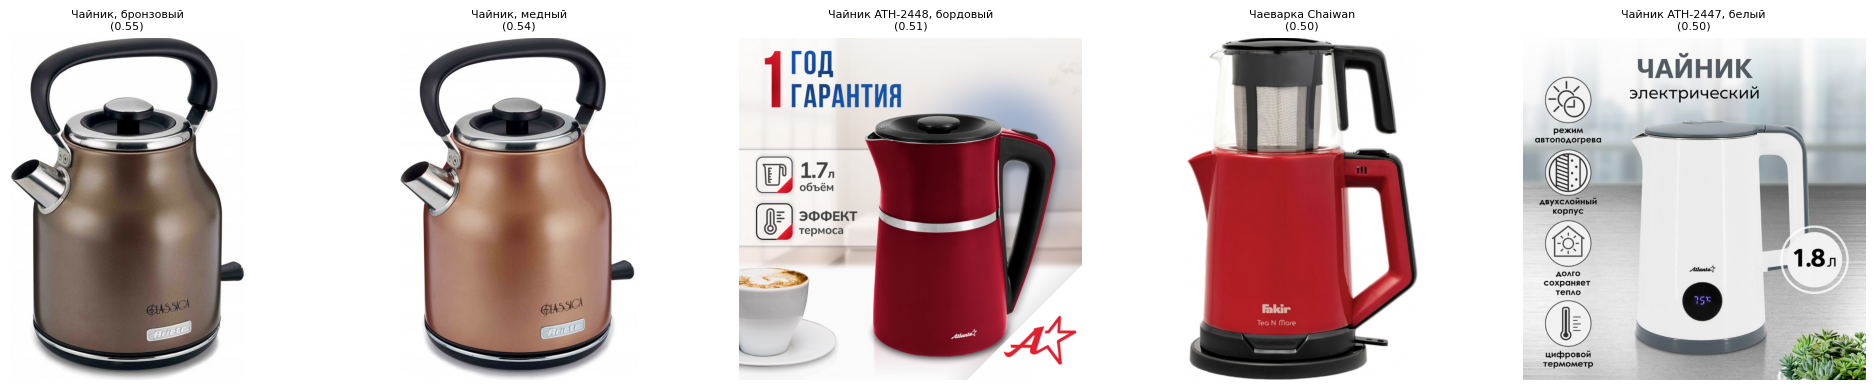

In [65]:
show_results(top_results)

#### RUSSIAN

In [67]:
query = "монитор" # monitor
query_emb = encode_text_query(query, flip_dual_encoder)

# Compute cosine similarities
sims = cosine_similarity([query_emb], image_embs_array).flatten()

✅ Text embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'NoneType'> None
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


In [68]:
top_k_indices = sims.argsort()[-5:][::-1]
top_results = all_products_combined.iloc[top_k_indices][['title', 'windows_image_path']]
top_results['similarity'] = sims[top_k_indices]

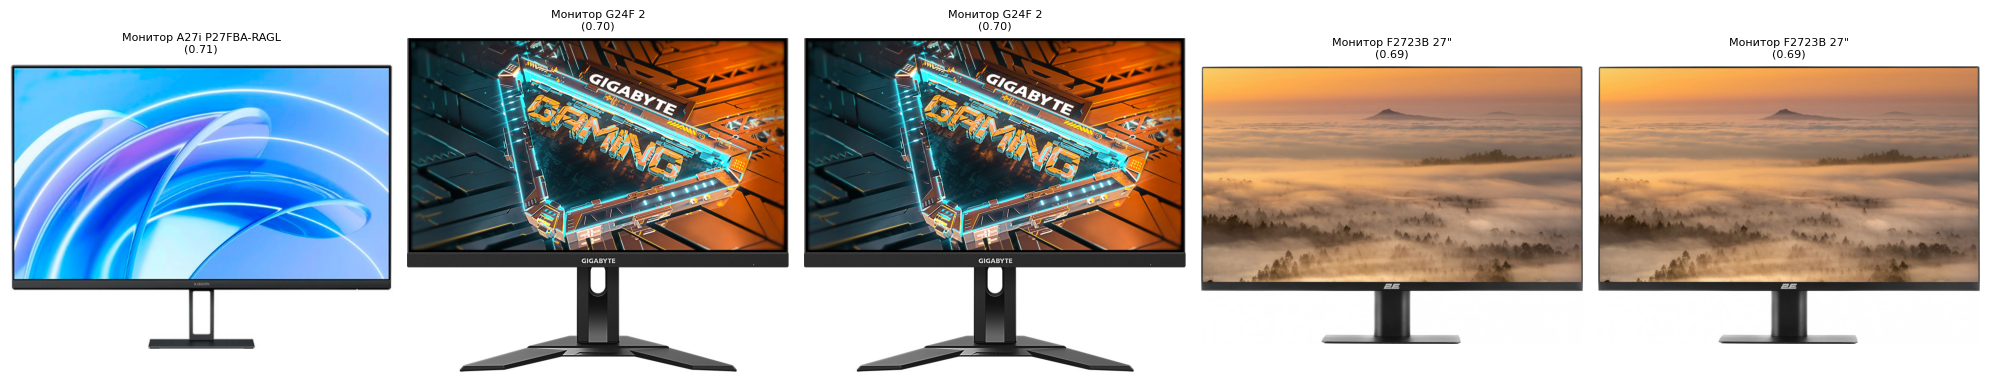

In [69]:
show_results(top_results)

#### KOREAN

In [74]:
query = "인공 꽃" #artificial flowers
query_emb = encode_text_query(query, flip_dual_encoder)

# Compute cosine similarities
sims = cosine_similarity([query_emb], image_embs_array).flatten()

✅ Text embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'NoneType'> None
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


In [75]:
top_k_indices = sims.argsort()[-5:][::-1]
top_results = all_products_combined.iloc[top_k_indices][['title', 'windows_image_path']]
top_results['similarity'] = sims[top_k_indices]

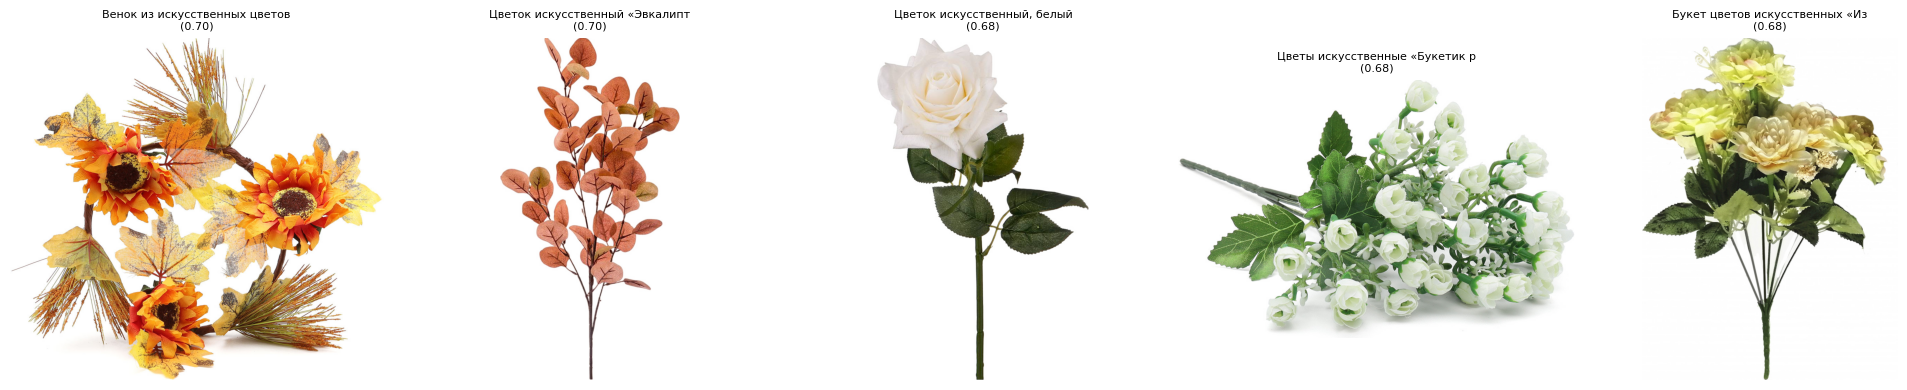

In [76]:
show_results(top_results)

#### GERMAN

In [78]:
query = "Kopfhörer" #earphones
query_emb = encode_text_query(query, flip_dual_encoder)

# Compute cosine similarities
sims = cosine_similarity([query_emb], image_embs_array).flatten()

✅ Text embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'NoneType'> None
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


In [79]:
top_k_indices = sims.argsort()[-5:][::-1]
top_results = all_products_combined.iloc[top_k_indices][['title', 'windows_image_path']]
top_results['similarity'] = sims[top_k_indices]

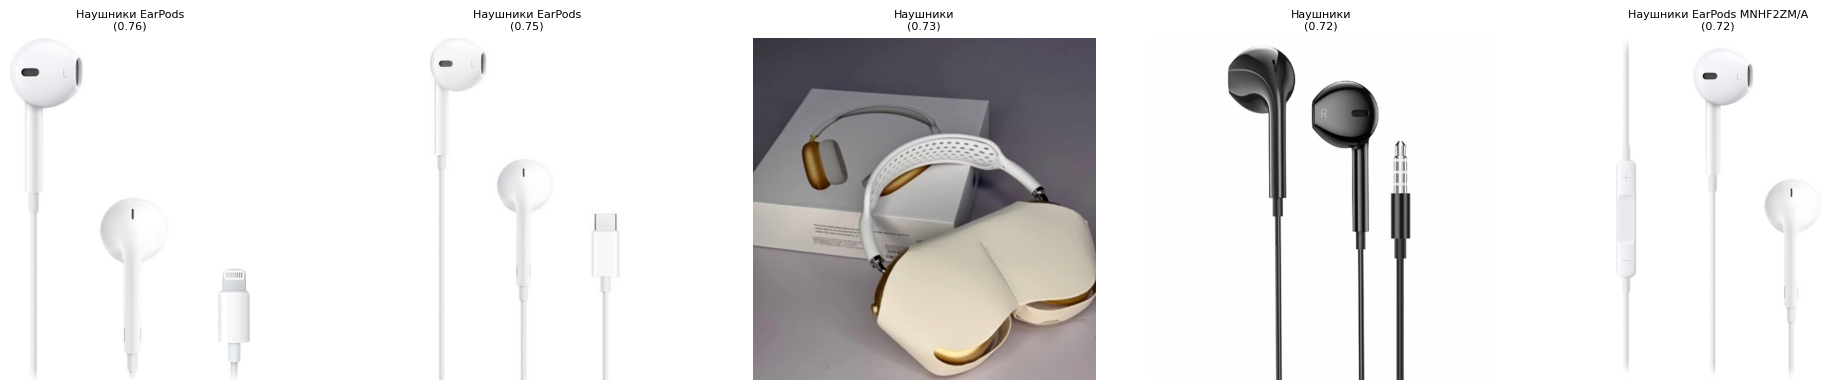

In [80]:
show_results(top_results)

#### ARABIC

In [88]:
query = "أحذية سوداء" #black boots
query_emb = encode_text_query(query, flip_dual_encoder)

# Compute cosine similarities
sims = cosine_similarity([query_emb], image_embs_array).flatten()

✅ Text embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'NoneType'> None
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


In [89]:
top_k_indices = sims.argsort()[-5:][::-1]
top_results = all_products_combined.iloc[top_k_indices][['title', 'windows_image_path']]
top_results['similarity'] = sims[top_k_indices]

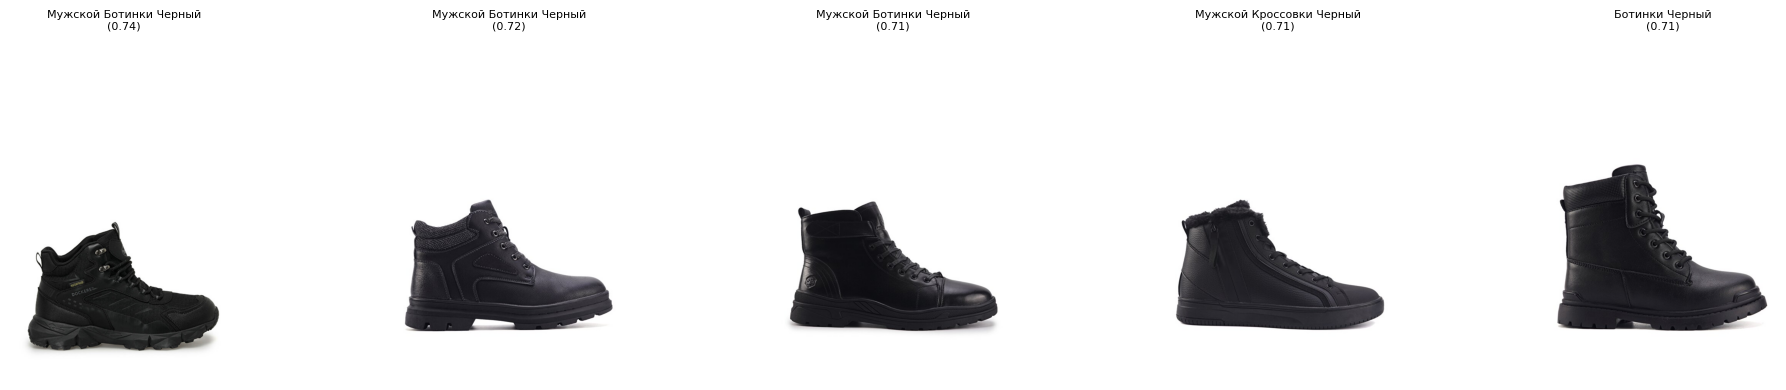

In [90]:
show_results(top_results)

### EMBEDDING FEATURE SPACE

In [134]:
test_images_paths = [r"C:\Users\User\Downloads\7285_013_1__83197.jpg",
                     r"C:\Users\User\Downloads\das-keyboard-6-professional-main.jpg",
                     r"C:\Users\User\Downloads\Screenshot 2025-07-16 183502.jpg",
                     r"C:\Users\User\Downloads\Screenshot 2025-07-16 183621.jpg",
                     r"C:\Users\User\Downloads\orange sneakers.jpg",
                     r"C:\Users\User\Downloads\earphones.jpg",
                     r"C:\Users\User\Downloads\beige woman bag.jpg"]

test_images_labels = ['حمالة صدر سوداء', #black woman bra
                      'black keyboard',
                      'белые штаны', #white plants 
                      'черная футболка', #black tshirt
                      'orange sneakers', 
                      'earphones',
                      'beige woman bag']


✅ Image embedding: torch.Size([1, 256])
✅ Text embedding: torch.Size([1, 256])


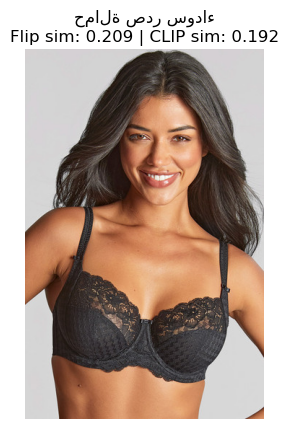

✅ Image embedding: torch.Size([1, 256])
✅ Text embedding: torch.Size([1, 256])


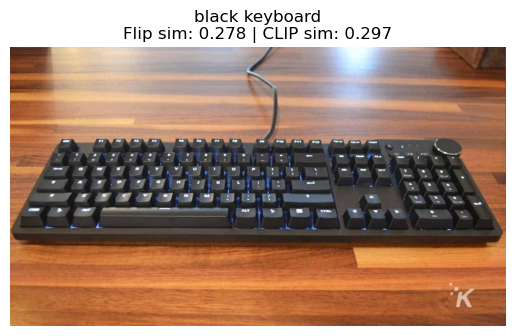

✅ Image embedding: torch.Size([1, 256])
✅ Text embedding: torch.Size([1, 256])


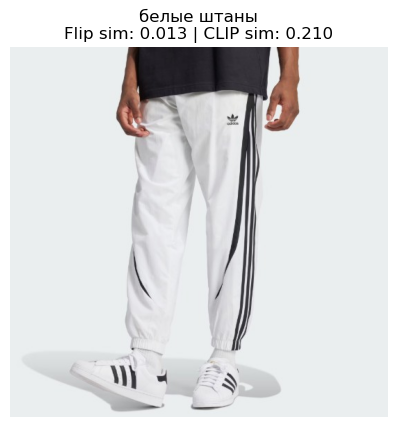

✅ Image embedding: torch.Size([1, 256])
✅ Text embedding: torch.Size([1, 256])


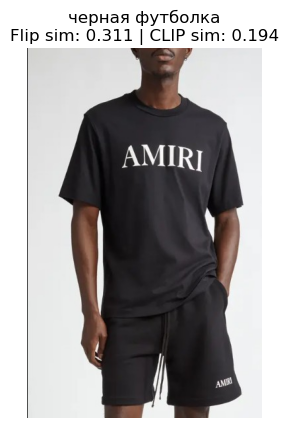

✅ Image embedding: torch.Size([1, 256])
✅ Text embedding: torch.Size([1, 256])


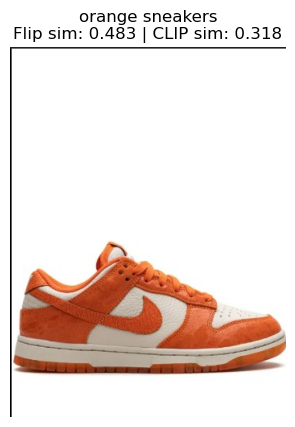

✅ Image embedding: torch.Size([1, 256])
✅ Text embedding: torch.Size([1, 256])


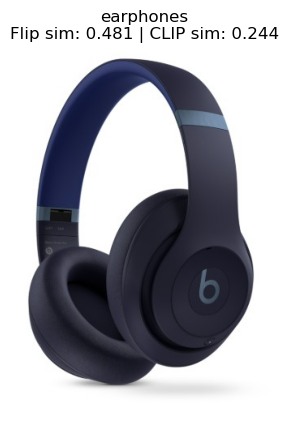

✅ Image embedding: torch.Size([1, 256])
✅ Text embedding: torch.Size([1, 256])


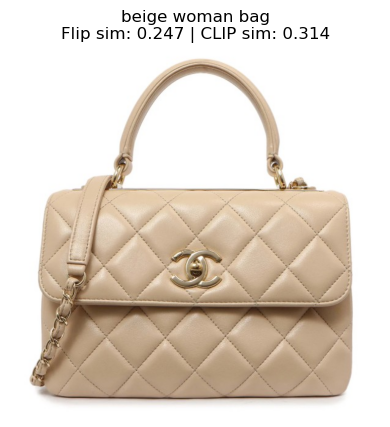

In [135]:
import torchvision.transforms as T
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
import torch

# Use CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flip_dual_encoder = flip_dual_encoder.to(device)
clip_model = clip_model.to(device)  # Ensure CLIP model is also on the same device

flip_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Loop through each image–text pair
for img_path, label in zip(test_images_paths, test_images_labels):
    image = Image.open(img_path).convert("RGB")

    # ----- CLIP -----
    clip_inputs = clip_processor(images=image, text=[label], return_tensors="pt", padding=True)
    clip_inputs = {k: v.to(device) for k, v in clip_inputs.items()}

    with torch.no_grad():
        clip_outputs = clip_model(**clip_inputs)
        clip_image_embed = F.normalize(clip_outputs.image_embeds[0], dim=-1)
        clip_text_embed = F.normalize(clip_outputs.text_embeds[0], dim=-1)
        clip_sim = F.cosine_similarity(clip_image_embed, clip_text_embed, dim=0).item()

    # ----- Flip -----
    image_tensor = flip_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        flip_img_embed, flip_txt_embed = flip_dual_encoder(images=image_tensor, texts=[label])

        if flip_txt_embed is None:
            print(f"⚠️ Warning: Text embedding failed for label '{label}'")
            continue

        flip_sim = F.cosine_similarity(flip_img_embed[0], flip_txt_embed[0], dim=0).item()

    # ----- Display -----
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{label}\nFlip sim: {flip_sim:.3f} | CLIP sim: {clip_sim:.3f}")
    plt.show()
